# raw_data.csv 전처리

처리 단계:
1. 원본 데이터와 필수 컬럼 확인
2. 문자열, 업종명, 날짜 형식 정리
3. 금액과 건수의 자료형 및 값 검증
4. 중복과 업종 코드-명칭 매핑 검증
5. 분석용 파생변수 생성
6. 전처리 결과와 품질 리포트 저장

In [1]:
from pathlib import Path
import json
import math

import pandas as pd

# 노트북을 루트 또는 notebooks/에서 실행해도 프로젝트 루트를 찾습니다.
PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / 'data').exists() and (PROJECT_ROOT.parent / 'data').exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

INPUT_PATH = PROJECT_ROOT / 'data/raw/raw_data.csv'
OUTPUT_PATH = PROJECT_ROOT / 'data/processed/preprocessed_data.csv'
REPORT_PATH = PROJECT_ROOT / 'reports/preprocessing_report.json'

In [2]:
# 분석에 반드시 필요한 컬럼과 데이터의 자연스러운 grain을 정의합니다.
REQUIRED_COLUMNS = [
    'STRD_YYMM', 'SIDO_NM', 'CCG_NM', 'GENDER_CD', 'AGE_CD',
    'TP_BUZ_NO', 'TP_BUZ_NM', 'amt', 'cnt'
]
GRAIN_COLUMNS = [
    'STRD_YYMM', 'SIDO_NM', 'CCG_NM', 'GENDER_CD',
    'AGE_CD', 'TP_BUZ_NO'
]

df = pd.read_csv(INPUT_PATH, dtype=str, encoding='utf-8-sig')
missing_columns = [column for column in REQUIRED_COLUMNS if column not in df.columns]
if missing_columns:
    raise ValueError(f'Missing required columns: {missing_columns}')

# 분석 대상 컬럼만 사용해 예기치 않은 컬럼의 영향을 차단합니다.
df = df[REQUIRED_COLUMNS].copy()
print(f'원본 행 수: {len(df):,}, 컬럼 수: {len(df.columns)}')

원본 행 수: 242,574, 컬럼 수: 9


In [ ]:
# 코드값과 수치형 컬럼을 정리하기 전에 문자열 양끝 공백을 제거
string_columns = [column for column in REQUIRED_COLUMNS if column not in {'amt', 'cnt'}]
for column in string_columns:
    df[column] = df[column].str.strip()

# 업종명에는 표현상의 공백이 포함되어 있어 비교를 위해 내부 공백도 제거
df['TP_BUZ_NM'] = df['TP_BUZ_NM'].str.replace(r'\s+', '', regex=True)

# YYMM 값을 월의 첫 날짜로 해석한 뒤, 분석용 YYYY-MM 문자열로 보관
df['month'] = pd.to_datetime(
    df['STRD_YYMM'] + '01', format='%Y%m%d', errors='coerce'
)
if df['month'].isna().any():
    bad_values = df.loc[df['month'].isna(), 'STRD_YYMM'].unique().tolist()
    raise ValueError(f'Invalid STRD_YYMM values: {bad_values}')
df['month'] = df['month'].dt.strftime('%Y-%m')

print('월 범위:', df['month'].min(), '~', df['month'].max())

월 범위: 2026-01 ~ 2026-06


In [4]:
# amt와 cnt는 집계 수치이므로 숫자로 변환하고 결측 및 0 이하 값을 차단합니다.
for column in ['amt', 'cnt']:
    df[column] = pd.to_numeric(df[column], errors='coerce')
    if df[column].isna().any():
        raise ValueError(f'Non-numeric or missing values found in {column}')
    if (df[column] <= 0).any():
        raise ValueError(f'Non-positive values found in {column}')
    df[column] = df[column].astype('int64')

missing_values = df[REQUIRED_COLUMNS].isna().sum()
if missing_values.any():
    raise ValueError(
        f'Missing values found: {missing_values[missing_values > 0].to_dict()}'
    )

print('결측치:', int(df.isna().sum().sum()))
print('amt 중앙값:', int(df['amt'].median()))
print('cnt 중앙값:', int(df['cnt'].median()))

결측치: 0
amt 중앙값: 16000000
cnt 중앙값: 810


In [5]:
# 한 행이 하나의 분석 grain을 나타내는지 확인합니다.
duplicate_count = int(df.duplicated(GRAIN_COLUMNS).sum())
if duplicate_count:
    raise ValueError(f'Duplicate business-grain rows found: {duplicate_count}')

# 업종 코드는 하나의 업종명과만 연결되어야 합니다.
code_name_conflicts = df.groupby('TP_BUZ_NO')['TP_BUZ_NM'].nunique() > 1
if code_name_conflicts.any():
    bad_codes = code_name_conflicts[code_name_conflicts].index.tolist()
    raise ValueError(f'Multiple business names found for codes: {bad_codes}')

print('분석 grain 중복 행:', duplicate_count)
print('업종 코드 수:', df['TP_BUZ_NO'].nunique())

분석 grain 중복 행: 0
업종 코드 수: 11


In [6]:
# x는 성별과 연령을 알 수 없는 집계 행이므로 원본 코드는 유지하고 별도 플래그를 만듭니다.
df['unknown_demo'] = (df['GENDER_CD'] == 'x') & (df['AGE_CD'] == 'x')

# 행별 건당 금액을 계산합니다. 집계 시에는 sum(amt) / sum(cnt)를 사용해야 합니다.
df['avg_amt_per_cnt'] = df['amt'] / df['cnt']

# 오른쪽 꼬리가 긴 금액과 건수를 시각화할 수 있도록 로그 변수를 추가합니다.
df['log_amt'] = (df['amt'] + 1).map(math.log)
df['log_cnt'] = (df['cnt'] + 1).map(math.log)

output_columns = REQUIRED_COLUMNS + [
    'month', 'unknown_demo', 'avg_amt_per_cnt', 'log_amt', 'log_cnt'
]
df = df[output_columns]
print('미상 인구통계 행:', int(df['unknown_demo'].sum()))
df.head()

미상 인구통계 행: 13161


,STRD_YYMM,SIDO_NM,CCG_NM,GENDER_CD,AGE_CD,TP_BUZ_NO,TP_BUZ_NM,amt,cnt,month,unknown_demo,avg_amt_per_cnt,log_amt,log_cnt
0,202605,서울특별시,용산구,2,3,8006,서양음식,734430000,38874,2026-05,False,18892.576015,20.414605,10.568107
1,202605,부산광역시,사상구,2,4,8001,일반한식,424220000,10929,2026-05,False,38815.994144,19.865763,9.299267
2,202601,경상북도,포항시 북구,1,5,4010,편의점,283030000,29848,2026-01,False,9482.377379,19.461063,10.303907
3,202601,전라남도,여수시,1,6,4010,편의점,204060000,20727,2026-01,False,9845.129541,19.133925,9.939241
4,202606,서울특별시,송파구,1,3,4010,편의점,575120000,86780,2026-06,False,6627.333487,20.170089,11.371143


In [7]:
# 재현 가능한 품질 리포트를 만들고 정제 데이터를 저장합니다.
report = {
    'input_rows': int(len(df)),
    'output_rows': int(len(df)),
    'columns': output_columns,
    'duplicate_business_grain_rows': duplicate_count,
    'missing_values': {
        column: int(count)
        for column, count in df.isna().sum().items()
        if count
    },
    'unknown_demo_rows': int(df['unknown_demo'].sum()),
    'month_counts': {
        str(key): int(value)
        for key, value in df['month'].value_counts().sort_index().items()
    },
    'amount_summary': {
        'min': int(df['amt'].min()),
        'median': float(df['amt'].median()),
        'max': int(df['amt'].max()),
    },
    'count_summary': {
        'min': int(df['cnt'].min()),
        'median': float(df['cnt'].median()),
        'max': int(df['cnt'].max()),
    },
}

df.to_csv(OUTPUT_PATH, index=False, encoding='utf-8-sig')
REPORT_PATH.write_text(
    json.dumps(report, ensure_ascii=False, indent=2), encoding='utf-8'
)
print(f'저장 완료: {OUTPUT_PATH} ({len(df):,}행)')
print(f'리포트 저장 완료: {REPORT_PATH}')

저장 완료: d:\bc\data\processed\preprocessed_data.csv (242,574행)
리포트 저장 완료: d:\bc\reports\preprocessing_report.json


## 결과 확인

행 수, 결측치, 분석 grain 중복을 마지막으로 확인합니다.

In [8]:
assert len(df) == report['output_rows']
assert int(df.isna().sum().sum()) == 0
assert duplicate_count == 0
print('최종 검증 통과')
print(df.shape)

최종 검증 통과
(242574, 14)


## EDA: 주요 패턴 확인

전처리된 `df`를 기준으로 월별, 지역별, 업종별, 인구통계별 소비 규모와 건당 금액을 확인합니다.

> 집계된 건당 금액은 행별 평균의 평균이 아니라 `sum(amt) / sum(cnt)`로 계산합니다.

In [ ]:
import matplotlib.pyplot as plt
from IPython.display import display

# 집계 금액과 건수를 사용해 가중 평균 건당 금액을 계산합니다.
def summarize_by(group_columns):
    summary = (
        df.groupby(group_columns, as_index=False)
        .agg(
            row_count=('amt', 'size'),
            total_amt=('amt', 'sum'),
            total_cnt=('cnt', 'sum'),
        )
    )
    summary['avg_amt_per_cnt'] = summary['total_amt'] / summary['total_cnt']
    summary['amt_share'] = summary['total_amt'] / summary['total_amt'].sum()
    return summary

# 결과 이미지와 요약표를 reports 폴더에 저장합니다.
EDA_OUTPUT_DIR = PROJECT_ROOT / 'reports'
EDA_OUTPUT_DIR.mkdir(exist_ok=True)
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

In [11]:
# 1) 월별 추이: 규모와 가중 건당 금액을 함께 확인합니다.
monthly_summary = summarize_by(['month']).sort_values('month')
monthly_summary['mom_amt_change'] = monthly_summary['total_amt'].pct_change()
monthly_summary['mom_cnt_change'] = monthly_summary['total_cnt'].pct_change()

print('월별 요약')
display(monthly_summary.style.format({
    'total_amt': '{:,.0f}',
    'total_cnt': '{:,.0f}',
    'avg_amt_per_cnt': '{:,.0f}',
    'amt_share': '{:.1%}',
    'mom_amt_change': '{:.1%}',
    'mom_cnt_change': '{:.1%}',
}))

월별 요약


,month,row_count,total_amt,total_cnt,avg_amt_per_cnt,amt_share,mom_amt_change,mom_cnt_change
0,2026-01,40267,"2,819,035,480,000","148,307,836","19,008",16.4%,nan%,nan%
1,2026-02,40160,"2,668,138,270,000","138,483,094","19,267",15.5%,-5.4%,-6.6%
2,2026-03,40433,"2,858,668,760,000","159,859,550","17,882",16.6%,7.1%,15.4%
3,2026-04,40507,"2,827,034,240,000","162,268,230","17,422",16.4%,-1.1%,1.5%
4,2026-05,40696,"3,209,981,290,000","175,318,857","18,309",18.6%,13.5%,8.0%
5,2026-06,40511,"2,842,042,030,000","164,867,501","17,238",16.5%,-11.5%,-6.0%


In [12]:
# 2) 지역·업종별 요약: 총액이 큰 집단과 건당 금액이 큰 집단을 구분합니다.
region_summary = summarize_by(['SIDO_NM']).sort_values('total_amt', ascending=False)
business_summary = summarize_by(['TP_BUZ_NO', 'TP_BUZ_NM']).sort_values(
    'total_amt', ascending=False
)

print('총금액 기준 상위 시도')
display(region_summary.head(10).style.format({
    'total_amt': '{:,.0f}',
    'total_cnt': '{:,.0f}',
    'avg_amt_per_cnt': '{:,.0f}',
    'amt_share': '{:.1%}',
}))

print('총금액 기준 상위 업종')
display(business_summary.style.format({
    'total_amt': '{:,.0f}',
    'total_cnt': '{:,.0f}',
    'avg_amt_per_cnt': '{:,.0f}',
    'amt_share': '{:.1%}',
}))

# 3) 인구통계별 요약: 미상 집단은 별도 범주로 유지합니다.
demo_summary = summarize_by(['GENDER_CD', 'AGE_CD', 'unknown_demo'])
demo_summary = demo_summary.sort_values('total_amt', ascending=False)
print('인구통계별 총금액 상위 조합')
display(demo_summary.head(15).style.format({
    'total_amt': '{:,.0f}',
    'total_cnt': '{:,.0f}',
    'avg_amt_per_cnt': '{:,.0f}',
    'amt_share': '{:.1%}',
}))

총금액 기준 상위 시도


,SIDO_NM,row_count,total_amt,total_cnt,avg_amt_per_cnt,amt_share
1,경기도,47005,"3,961,619,780,000","214,676,356","18,454",23.0%
8,서울특별시,25792,"3,145,138,600,000","195,942,696","16,051",18.3%
7,부산광역시,17046,"1,710,369,500,000","98,672,679","17,334",9.9%
2,경상남도,20475,"1,096,811,490,000","55,264,724","19,847",6.4%
5,대구광역시,8807,"1,071,637,900,000","61,612,589","17,393",6.2%
3,경상북도,20113,"886,415,130,000","45,093,776","19,657",5.1%
11,인천광역시,9623,"811,162,700,000","47,123,986","17,213",4.7%
4,광주광역시,5100,"649,137,580,000","36,471,747","17,798",3.8%
15,충청남도,14862,"616,243,420,000","31,790,306","19,385",3.6%
12,전라남도,18357,"564,959,030,000","24,870,428","22,716",3.3%


총금액 기준 상위 업종


,TP_BUZ_NO,TP_BUZ_NM,row_count,total_amt,total_cnt,avg_amt_per_cnt,amt_share
3,8001,일반한식,28406,"6,348,450,610,000","173,301,016","36,633",36.9%
2,4020,슈퍼마켓,28456,"2,723,898,860,000","143,282,938","19,011",15.8%
1,4010,편의점,28967,"2,483,898,980,000","306,005,921","8,117",14.4%
8,8006,서양음식,28627,"1,916,074,350,000","174,739,374","10,965",11.1%
0,4004,대형할인점,21529,"1,654,789,730,000","47,906,339","34,542",9.6%
9,8021,스넥,27438,"571,506,890,000","35,722,693","15,998",3.3%
7,8005,중국음식,26805,"529,612,890,000","18,567,799","28,523",3.1%
10,8301,제과점,27224,"498,417,820,000","39,671,152","12,564",2.9%
6,8004,일식회집,21714,"487,750,290,000","9,769,473","49,926",2.8%
4,8002,갈비전문점,2860,"9,269,650,000","122,645","75,581",0.1%


인구통계별 총금액 상위 조합


,GENDER_CD,AGE_CD,unknown_demo,row_count,total_amt,total_cnt,avg_amt_per_cnt,amt_share
4,1,5,False,13929,"2,332,862,140,000","120,899,752","19,296",13.5%
5,1,6,False,14044,"2,331,087,740,000","108,459,324","21,493",13.5%
3,1,4,False,13679,"1,952,102,740,000","106,111,833","18,397",11.3%
11,2,6,False,13729,"1,755,472,760,000","76,527,506","22,939",10.2%
10,2,5,False,13633,"1,535,037,270,000","75,502,045","20,331",8.9%
2,1,3,False,13480,"1,360,568,200,000","83,698,500","16,256",7.9%
9,2,4,False,13442,"1,265,233,230,000","69,503,803","18,204",7.3%
18,x,x,True,13161,"1,056,216,910,000","65,217,271","16,195",6.1%
8,2,3,False,13291,"895,907,120,000","53,726,661","16,675",5.2%
1,1,2,False,13241,"745,423,860,000","55,588,332","13,410",4.3%


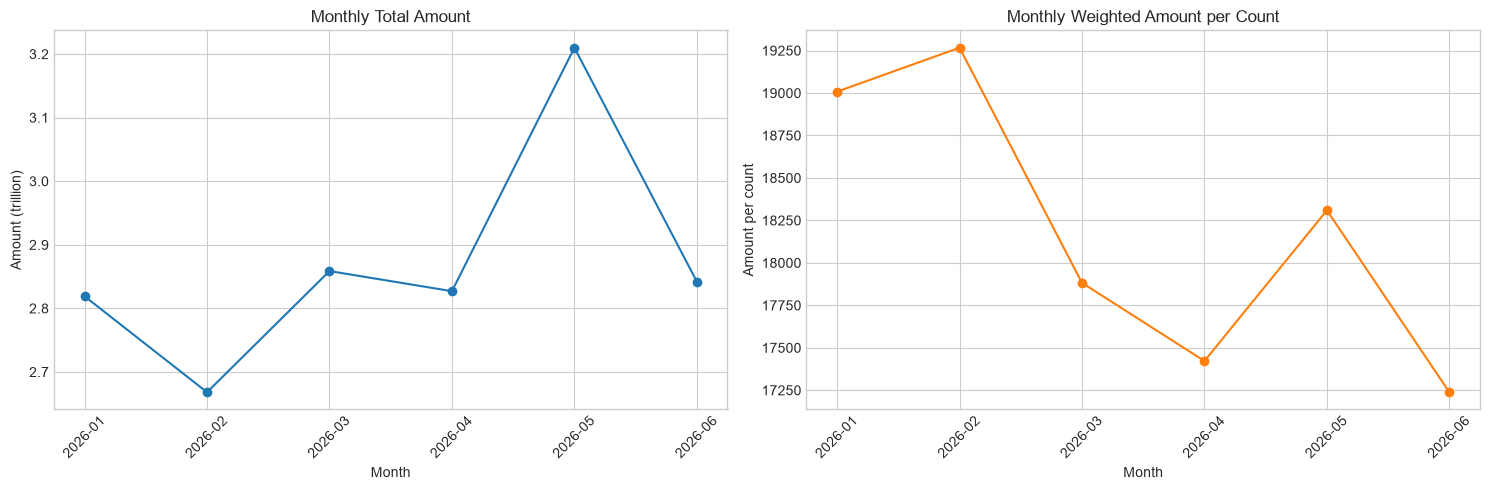

C:\Users\beomj\AppData\Local\Temp\ipykernel_13912\2528065055.py:43: UserWarning: Glyph 51204 (\N{HANGUL SYLLABLE JEON}) missing from font(s) Arial.
  fig.tight_layout()
C:\Users\beomj\AppData\Local\Temp\ipykernel_13912\2528065055.py:43: UserWarning: Glyph 46972 (\N{HANGUL SYLLABLE RA}) missing from font(s) Arial.
  fig.tight_layout()
C:\Users\beomj\AppData\Local\Temp\ipykernel_13912\2528065055.py:43: UserWarning: Glyph 45224 (\N{HANGUL SYLLABLE NAM}) missing from font(s) Arial.
  fig.tight_layout()
C:\Users\beomj\AppData\Local\Temp\ipykernel_13912\2528065055.py:43: UserWarning: Glyph 46020 (\N{HANGUL SYLLABLE DO}) missing from font(s) Arial.
  fig.tight_layout()
C:\Users\beomj\AppData\Local\Temp\ipykernel_13912\2528065055.py:43: UserWarning: Glyph 52649 (\N{HANGUL SYLLABLE CUNG}) missing from font(s) Arial.
  fig.tight_layout()
C:\Users\beomj\AppData\Local\Temp\ipykernel_13912\2528065055.py:43: UserWarning: Glyph 52397 (\N{HANGUL SYLLABLE CEONG}) missing from font(s) Arial.
  fig.tight

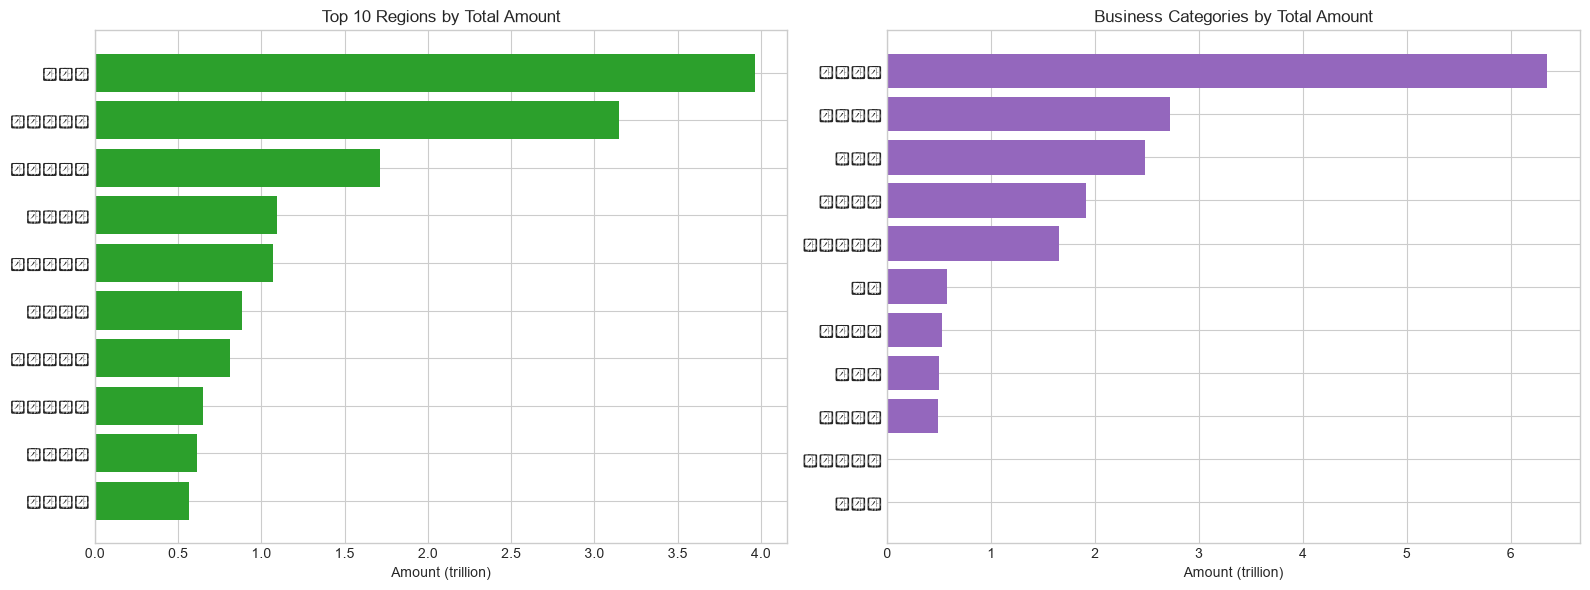

In [13]:
# 4) 핵심 차트를 저장합니다.
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

axes[0].plot(
    monthly_summary['month'],
    monthly_summary['total_amt'] / 1e12,
    marker='o',
    color='#1f77b4',
)
axes[0].set_title('Monthly Total Amount')
axes[0].set_xlabel('Month')
axes[0].set_ylabel('Amount (trillion)')
axes[0].tick_params(axis='x', rotation=45)

axes[1].plot(
    monthly_summary['month'],
    monthly_summary['avg_amt_per_cnt'],
    marker='o',
    color='#ff7f0e',
)
axes[1].set_title('Monthly Weighted Amount per Count')
axes[1].set_xlabel('Month')
axes[1].set_ylabel('Amount per count')
axes[1].tick_params(axis='x', rotation=45)

fig.tight_layout()
fig.savefig(EDA_OUTPUT_DIR / 'eda_monthly_trend.png', dpi=150, bbox_inches='tight')
plt.show()
plt.close(fig)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
region_top = region_summary.head(10).sort_values('total_amt')
business_top = business_summary.sort_values('total_amt')

axes[0].barh(region_top['SIDO_NM'], region_top['total_amt'] / 1e12, color='#2ca02c')
axes[0].set_title('Top 10 Regions by Total Amount')
axes[0].set_xlabel('Amount (trillion)')

axes[1].barh(business_top['TP_BUZ_NM'], business_top['total_amt'] / 1e12, color='#9467bd')
axes[1].set_title('Business Categories by Total Amount')
axes[1].set_xlabel('Amount (trillion)')

fig.tight_layout()
fig.savefig(EDA_OUTPUT_DIR / 'eda_region_business.png', dpi=150, bbox_inches='tight')
plt.show()
plt.close(fig)

In [ ]:
# 5) 재사용할 수 있도록 집계표와 핵심 수치를 파일로 저장합니다.
monthly_summary.to_csv(EDA_OUTPUT_DIR / 'eda_monthly_summary.csv', index=False, encoding='utf-8-sig')
region_summary.to_csv(EDA_OUTPUT_DIR / 'eda_region_summary.csv', index=False, encoding='utf-8-sig')
business_summary.to_csv(EDA_OUTPUT_DIR / 'eda_business_summary.csv', index=False, encoding='utf-8-sig')
demo_summary.to_csv(EDA_OUTPUT_DIR / 'eda_demographic_summary.csv', index=False, encoding='utf-8-sig')

eda_findings = {
    'highest_month_total_amt': str(monthly_summary.loc[monthly_summary['total_amt'].idxmax(), 'month']),
    'highest_month_total_amt_value': int(monthly_summary['total_amt'].max()),
    'highest_month_avg_amt_per_cnt': str(monthly_summary.loc[monthly_summary['avg_amt_per_cnt'].idxmax(), 'month']),
    'top_region_by_total_amt': str(region_summary.iloc[0]['SIDO_NM']),
    'top_business_by_total_amt': str(business_summary.iloc[0]['TP_BUZ_NM']),
    'top_region_amt_share': float(region_summary.iloc[0]['amt_share']),
    'top_business_amt_share': float(business_summary.iloc[0]['amt_share']),
}
(EDA_OUTPUT_DIR / 'eda_findings.json').write_text(
    json.dumps(eda_findings, ensure_ascii=False, indent=2),
    encoding='utf-8',
)

print('EDA 집계표, 핵심 수치, 차트 저장 완료')
print(json.dumps(eda_findings, ensure_ascii=False, indent=2))